# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sunpy.net import Fido, attrs as a
import astropy.units as u
import sunpy.map


In [ ]:
print(a.Instrument)

sunpy.net.attrs.Instrument

Specifies the Instrument name for the search.

       Attribute Name       ...
--------------------------- ...
adapt                       ...
aia                         ...
aia                         ...
bcs                         ...
be_continuum                ...
be_halpha                   ...
bigbear                     ...
c1                          ...
c2                          ...
caii                        ...
cds                         ...
celias                      ...
cerrotololo                 ...
chp                         ...
cook                        ...
costep                      ...
cp                          ...
dpm                         ...
eis                         ...
eit                         ...
elteide                     ...
erne                        ...
eui                         ...
eve                         ...
eve                         ...
film                        ...
five_12_channelmagnetograph .

In [ ]:
# Definimos el intervalo de tiempo (un rango pequeño para no colapsar)
tiempo = a.Time("2023-01-01 00:00:00", "2023-01-01 01:00:00")

# Query para HMI (Visible - 6173 Å)
query_hmi = Fido.search(tiempo, a.Instrument.hmi, a.Physobs.intensity)

# Query para AIA (Bandas de 1600, 1700 y 4500 Å)
# Estas son las únicas de AIA que sirven para ver la "superficie/cromosfera"
query_aia = Fido.search(tiempo, a.Instrument.aia, a.Wavelength(1600*u.angstrom, 4500*u.angstrom))

query_EVE = Fido.search(
    a.Time("2020-10-27", "2020-10-27"),
    a.Instrument("EVE")
)

In [4]:
query_hmi.show()

Start Time,End Time,Source,Instrument,Wavelength,Provider,Physobs,Wavetype,Extent Width,Extent Length,Extent Type,Size,fileid
,,,,Angstrom,,,,,,,Mibyte,
Time,Time,str3,str3,float64[2],str4,str9,str6,str4,str4,str8,float64,str29
2023-01-01 00:00:22.000,2023-01-01 00:00:23.000,SDO,HMI,6173.0 .. 6174.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,-0.00098,hmi__ic_45s:21037442:21037442
2023-01-01 00:01:07.000,2023-01-01 00:01:08.000,SDO,HMI,6173.0 .. 6174.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,-0.00098,hmi__ic_45s:21037443:21037443
2023-01-01 00:01:52.000,2023-01-01 00:01:53.000,SDO,HMI,6173.0 .. 6174.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,-0.00098,hmi__ic_45s:21037444:21037444
2023-01-01 00:02:37.000,2023-01-01 00:02:38.000,SDO,HMI,6173.0 .. 6174.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,-0.00098,hmi__ic_45s:21037445:21037445
2023-01-01 00:03:22.000,2023-01-01 00:03:23.000,SDO,HMI,6173.0 .. 6174.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,-0.00098,hmi__ic_45s:21037446:21037446
2023-01-01 00:04:07.000,2023-01-01 00:04:08.000,SDO,HMI,6173.0 .. 6174.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,-0.00098,hmi__ic_45s:21037447:21037447
2023-01-01 00:04:52.000,2023-01-01 00:04:53.000,SDO,HMI,6173.0 .. 6174.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,-0.00098,hmi__ic_45s:21037448:21037448
2023-01-01 00:05:37.000,2023-01-01 00:05:38.000,SDO,HMI,6173.0 .. 6174.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,-0.00098,hmi__ic_45s:21037449:21037449


In [5]:
query_aia.show()

Start Time,End Time,Source,Instrument,Wavelength,Provider,Physobs,Wavetype,Extent Width,Extent Length,Extent Type,Size,fileid
,,,,Angstrom,,,,,,,Mibyte,
Time,Time,str3,str3,float64[2],str4,str9,str6,str4,str4,str8,float64,str25
2023-01-01 00:00:05.000,2023-01-01 00:00:06.000,SDO,AIA,4500.0 .. 4500.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844,aia__lev1:4500:1451606443
2023-01-01 00:00:14.000,2023-01-01 00:00:15.000,SDO,AIA,1600.0 .. 1600.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844,aia__lev1:1600:1451606453
2023-01-01 00:00:28.000,2023-01-01 00:00:29.000,SDO,AIA,1700.0 .. 1700.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844,aia__lev1:1700:1451606466
2023-01-01 00:00:38.000,2023-01-01 00:00:39.000,SDO,AIA,1600.0 .. 1600.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844,aia__lev1:1600:1451606477
2023-01-01 00:00:52.000,2023-01-01 00:00:53.000,SDO,AIA,1700.0 .. 1700.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844,aia__lev1:1700:1451606490
2023-01-01 00:01:02.000,2023-01-01 00:01:03.000,SDO,AIA,1600.0 .. 1600.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844,aia__lev1:1600:1451606501
2023-01-01 00:01:16.000,2023-01-01 00:01:17.000,SDO,AIA,1700.0 .. 1700.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844,aia__lev1:1700:1451606514
2023-01-01 00:01:26.000,2023-01-01 00:01:27.000,SDO,AIA,1600.0 .. 1600.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844,aia__lev1:1600:1451606525


In [6]:
query_EVE.show()

Start Time,End Time,Source,Instrument,Wavelength,Provider,Physobs,Extent Type,Size,fileid
,,,,,,,,Mibyte,
Time,Time,str3,str3,object,str4,str10,str8,float64,str25
2020-10-27 00:00:00.000,2020-10-28 00:00:00.000,SDO,EVE,[ 1. 304.] Angstrom,LASP,irradiance,FULLDISK,-0.00098,EVE_L1_esp_2020301_00
2020-10-27 00:00:00.000,2020-10-28 00:00:00.000,SDO,EVE,[ 93. 1033.] Angstrom,LASP,irradiance,FULLDISK,-0.00098,EVE_L2_lines_2020301_00
2020-10-27 00:00:00.000,2020-10-28 00:00:00.000,SDO,EVE,[ 60. 1060.] Angstrom,LASP,irradiance,FULLDISK,-0.00098,EVE_L2_spectra_2020301_00
2020-10-27 00:00:00.000,2020-10-28 00:00:00.000,SDO,EVE,[1.00e+00 1.05e+03] Angstrom,LASP,irradiance,FULLDISK,-0.00098,EVE_L3_0_2020301_00
2020-10-27 00:00:00.000,2020-10-28 00:00:00.000,SDO,EVE,None,LASP,irradiance,FULLDISK,-0.00098,EVE_L4_0_2020301_00


In [7]:
np.unique(query_aia[0]['Wavelength'])

<Quantity [1600., 1700., 4500.] Angstrom>

In [8]:
query_hmi[0,0] 

Start Time,End Time,Source,Instrument,Wavelength,Provider,Physobs,Wavetype,Extent Width,Extent Length,Extent Type,Size,fileid
,,,,Angstrom,,,,,,,Mibyte,
Time,Time,str3,str3,float64[2],str4,str9,str6,str4,str4,str8,float64,str29
2023-01-01 00:00:22.000,2023-01-01 00:00:23.000,SDO,HMI,6173.0 .. 6174.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,-0.00098,hmi__ic_45s:21037442:21037442


In [9]:
# 1. Seleccionamos solo el primer registro de la tabla (índice 0)
# Esto evita descargar los 1920 archivos de golpe.
solo_uno = query_hmi[0, 0] 

# 2. Descargamos el archivo
# 'path' es la carpeta donde se guardará. Si no existe, SunPy la crea.
descarga = Fido.fetch(solo_uno, path='./data/')

# 3. Verificar la ruta del archivo descargado
print(f"Archivo descargado en: {descarga[0]}")

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Archivo descargado en: data/hmi.ic_45s.2023.01.01_00_01_30_TAI.continuum.fits


Instrumento: HMI FRONT2
Unidades de los datos: DN / s


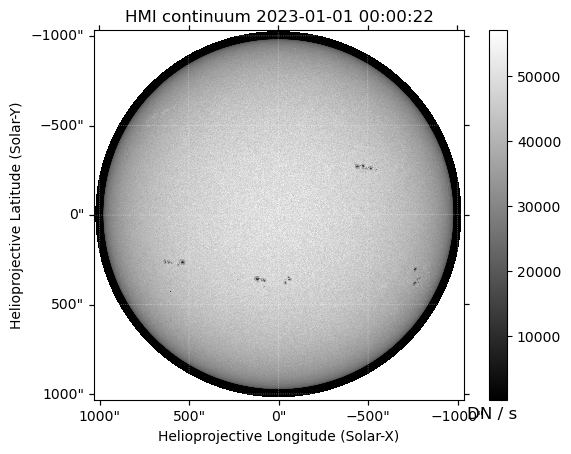

In [ ]:
# Cargamos el archivo descargado
hmi_map = sunpy.map.Map(descarga[0])

# Ver los metadatos principales
print(f"Instrumento: {hmi_map.instrument}")
print(f"Unidades de los datos: {hmi_map.unit}")

# Dibujar la imagen para verificar que todo esté bien
hmi_map.peek()

In [11]:
print(hmi_map.meta)


('xtension': 'IMAGE')
('bitpix': '16')
('naxis': '2')
('naxis1': '4096')
('naxis2': '4096')
('pcount': '0')
('gcount': '1')
('date': '2023-01-05T09:53:59')
('date-obs': '2023-01-01T00:00:22.10')
('telescop': 'SDO/HMI')
('instrume': 'HMI_FRONT2')
('wavelnth': '6173.0')
('camera': '2')
('bunit': 'DN/s')
('origin': 'SDO/JSOC-SDP')
('content': 'CONTINUUM INTENSITY')
('quality': '0')
('quallev1': '0')
('history': 'Polynomial Coefficients used for Doppler velocity correction: 3.302505e+
02 4.327883e-03 -1.138138e-05 -7.537716e-10')
('comment': 'De-rotation: ON; Un-distortion: ON; Re-centering: ON; Re-sizing: OFF; co
rrection for cosmic-ray hits; correction front/side intensity implemente
d for mod L; RSUNerr=5.0 pixels; dpath=/home/jsoc/cvs/Development/JSOC/p
roj/lev1.5_hmi/apps/; linearity=1 with coefficients updated on 2014/01/1
5; smooth=1; propagate eclipse bit from level 1; use of larger crop radi
us look-up tables')
('bld_vers': '-905')
('hcamid': '3')
('source': 'hmi.lev1[:#307649402,

[como descargar jsoc](https://docs.sunpy.org/en/stable/tutorial/acquiring_data/jsoc.html)

[plotear los datos](https://docs.sunpy.org/en/stable/generated/gallery/map/composite_map_AIA_HMI.html)